# Zarr Access

Make sure you have installed the optional dependencies

```bash
pip install herbie-data[zarr]

# or

uv add herbie-data[zarr]
```

In [1]:
from datetime import datetime, timedelta

from herbie.v2 import HRRR

In [2]:
# Show what's available?
HRRR.list_zarr_sources()

HRRR Zarr Sources                                                                                                  
                                                                                                                   
  source      product    Description                                   URL                                         
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  dynamical   analysis   dynamical.org HRRR analysis | 2014–present    ]8;id=69897;https://data.dynamical.org/noaa/hrrr/analysis/latest.zarr\https://data.dynamical.org/noaa/hrrr/analy]8;;\  
                         | 1-hr | dims: time × y × x                   ]8;id=248408;https://data.dynamical.org/noaa/hrrr/analysis/latest.zarr\sis/latest.zarr]8;;\                             
  dynamical   forecast   dynamical.org HRRR 48-hr forecast |           ]8;id=508383;https://data.dynamical.org/noaa/hrrr/forecast-48-hour/latest.zarr\https://data.dynamical.org/noaa/hrrr/forec]8;;\  
                         2018–present | 00/06/12/18Z only | dims:      ]8;id=479276;https://data.dynamical.org/noaa/hrrr/forecast-48-hour/latest.zarr\ast-48-hour/latest.zarr]8;;\                     
                         init_time × lead_time × y × x                                                             
  mesowest    analysis   Utah/MesoWest hrrrzarr | 2015–present |       ]8;id=764083;s3://hrrrzarr/sfc/\s3://hrrrzarr/sfc/]8;;\                          
                         per-variable | pass date=, variable=,                                                     
                         level= to from_zarr()                                                                     
  mesowest    forecast   Utah/MesoWest hrrrzarr | 2015–present |       ]8;id=838278;s3://hrrrzarr/sfc/\s3://hrrrzarr/sfc/]8;;\                          
                         per-variable | pass date=, variable=,                                                     
                         level= to from_zarr()                                                                    

## Dynamical HRRR Zarr Dataset

In [3]:
# ── Analysis (no lead-time dimension) ──────────────────────────────────────
ds = HRRR.from_zarr("dynamical", "analysis")
ds

Opening zarr → dynamical.org HRRR analysis | 2014–present | 1-hr | dims: time × y × x

<xarray.Dataset> Size: 20TB
Dimensions:                                     (time: 101476, y: 1059, x: 1799)
Coordinates:
  * time                                        (time) datetime64[ns] 812kB 2...
  * y                                           (y) float64 8kB 1.587e+06 ......
  * x                                           (x) float64 14kB -2.698e+06 ....
    latitude                                    (y, x) float32 8MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    longitude                                   (y, x) float32 8MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    spatial_ref                                 int64 8B ...
Data variables: (12/26)
    categorical_freezing_rain_surface           (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    categorical_ice_pellets_surface             (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    categorical_rain_surface                    (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    categorical_snow_surface                    (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    composite_reflectivity                      (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    dew_point_temperature_2m                    (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    ...                                          ...
    total_cloud_cover_atmosphere                (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    wind_gust_surface                           (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    wind_u_10m                                  (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    wind_u_80m                                  (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    wind_v_10m                                  (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
    wind_v_80m                                  (time, y, x) float32 773GB dask.array<chunksize=(2160, 45, 45), meta=np.ndarray>
Attributes:
    dataset_id:          noaa-hrrr-analysis
    dataset_version:     0.2.0
    name:                NOAA HRRR analysis
    description:         Analysis data from the High-Resolution Rapid Refresh...
    attribution:         NOAA NWS NCEP HRRR data processed by dynamical.org f...
    license:             CC-BY-4.0
    spatial_domain:      Continental United States
    spatial_resolution:  3 km
    time_domain:         2014-10-01 00:00:00 UTC to Present
    time_resolution:     1 hour

In [4]:
# dims: time, y, x  — slice to a moment:
t2m = (
    ds["temperature_2m"]
    .sel(time="2025-01-01T06")
    .isel(x=slice(150, 170), y=slice(150, 170))  # I have no idea where this is
)
t2m

<xarray.DataArray 'temperature_2m' (y: 20, x: 20)> Size: 2kB
dask.array<getitem, shape=(20, 20), dtype=float32, chunksize=(20, 20), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 160B 1.137e+06 1.134e+06 ... 1.083e+06 1.08e+06
  * x            (x) float64 160B -2.248e+06 -2.245e+06 ... -2.191e+06
    latitude     (y, x) float32 2kB dask.array<chunksize=(20, 20), meta=np.ndarray>
    longitude    (y, x) float32 2kB dask.array<chunksize=(20, 20), meta=np.ndarray>
    spatial_ref  int64 8B ...
    time         datetime64[ns] 8B 2025-01-01T06:00:00
Attributes:
    long_name:      2 metre temperature
    short_name:     2t
    standard_name:  air_temperature
    units:          degree_Celsius
    step_type:      instant

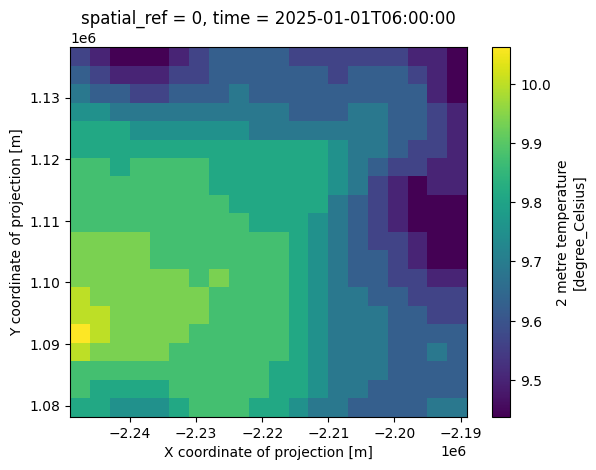

In [5]:
t2m.compute().plot()

In [6]:
# ── Forecast (init_time + lead_time) ───────────────────────────────────────
ds = HRRR.from_zarr("dynamical", "forecast")
# dims: init_time, lead_time, y, x
t2m = (
    ds["temperature_2m"]
    .sel(
        init_time=slice(datetime(2026, 1, 1), datetime(2026, 1, 2)),
        lead_time=timedelta(hours=6),
    )
    .isel(x=500, y=500)
)

t2m

Opening zarr → dynamical.org HRRR 48-hr forecast | 2018–present | 00/06/12/18Z only | dims: init_time × lead_time ×
y × x

<xarray.DataArray 'temperature_2m' (init_time: 5)> Size: 20B
dask.array<getitem, shape=(5,), dtype=float32, chunksize=(2,), chunktype=numpy.ndarray>
Coordinates:
  * init_time                 (init_time) datetime64[ns] 40B 2026-01-01 ... 2...
    expected_forecast_length  (init_time) timedelta64[ns] 40B dask.array<chunksize=(5,), meta=np.ndarray>
    ingested_forecast_length  (init_time) timedelta64[ns] 40B dask.array<chunksize=(5,), meta=np.ndarray>
    valid_time                (init_time) datetime64[ns] 40B dask.array<chunksize=(5,), meta=np.ndarray>
    latitude                  float32 4B dask.array<chunksize=(), meta=np.ndarray>
    lead_time                 timedelta64[ns] 8B 06:00:00
    longitude                 float32 4B dask.array<chunksize=(), meta=np.ndarray>
    spatial_ref               int64 8B ...
    x                         float64 8B -1.198e+06
    y                         float64 8B 8.669e+04
Attributes:
    long_name:      2 metre temperature
    short_name:     2t
    standard_name:  air_temperature
    units:          degree_Celsius
    step_type:      instant

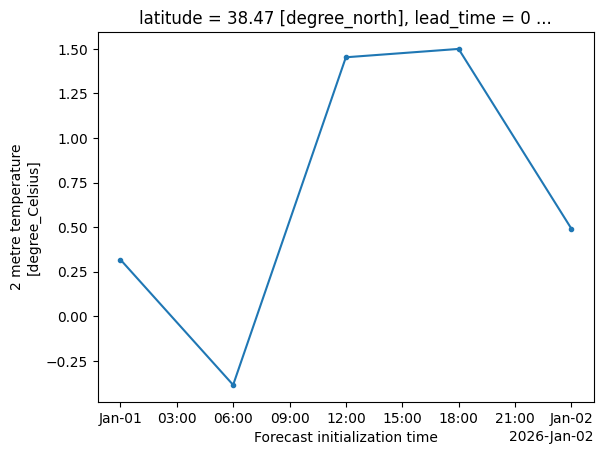

In [7]:
t2m.compute().plot(marker=".")

## MesoWest HRRR Zarr Dataset

In [8]:
# ── Utah zarr (one variable at a time, per date) ───────────────────────────
ds = HRRR.from_zarr(
    "mesowest",
    "analysis",
    date="2021-01-01 00:00",
    variable="TMP",
    level="surface",
)
ds


Opening zarr → Utah/MesoWest hrrrzarr | 2015–present | per-variable | pass date=, variable=, level= to from_zarr()

/home/blaylock/GITHUB/Herbie/src/herbie/v2/models/hrrr.py:60: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_mfdataset(


<xarray.Dataset> Size: 4MB
Dimensions:                  (projection_x_coordinate: 1799,
                              projection_y_coordinate: 1059)
Coordinates:
  * projection_x_coordinate  (projection_x_coordinate) float64 14kB -2.698e+0...
  * projection_y_coordinate  (projection_y_coordinate) float64 8kB -1.587e+06...
Data variables:
    forecast_period          timedelta64[ns] 8B ...
    forecast_reference_time  datetime64[ns] 8B ...
    height                   float64 8B ...
    pressure                 float64 8B ...
    time                     datetime64[ns] 8B ...
    TMP                      (projection_y_coordinate, projection_x_coordinate) float16 4MB dask.array<chunksize=(150, 150), meta=np.ndarray>

In [9]:
ds.TMP

<xarray.DataArray 'TMP' (projection_y_coordinate: 1059,
                         projection_x_coordinate: 1799)> Size: 4MB
dask.array<open_dataset-TMP, shape=(1059, 1799), dtype=float16, chunksize=(150, 150), chunktype=numpy.ndarray>
Coordinates:
  * projection_y_coordinate  (projection_y_coordinate) float64 8kB -1.587e+06...
  * projection_x_coordinate  (projection_x_coordinate) float64 14kB -2.698e+0...
Attributes:
    GRIB_PARAM:  [2, 0, 0, 0]
    long_name:   surface/TMP
    units:       K

## Dynamical GFS Zarr Dataset

In [5]:
from datetime import datetime, timedelta

from herbie.v2 import GFS

In [2]:
GFS.list_zarr_sources()

GFS Zarr Sources                                                                                                   
                                                                                                                   
  source      product    Description                                   URL                                         
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  dynamical   analysis   dynamical.org GFS analysis | 2021–present |   ]8;id=54666;https://data.dynamical.org/noaa/gfs/analysis/latest.zarr\https://data.dynamical.org/noaa/gfs/analys]8;;\  
                         1-hr | dims: time × latitude × longitude      ]8;id=583334;https://data.dynamical.org/noaa/gfs/analysis/latest.zarr\is/latest.zarr]8;;\                              
  dynamical   forecast   dynamical.org GFS forecast | 2021–present |   ]8;id=543417;https://data.dynamical.org/noaa/gfs/forecast/latest.zarr\https://data.dynamical.org/noaa/gfs/foreca]8;;\  
                         00/06/12/18Z | 0–384 h lead | dims:           ]8;id=326550;https://data.dynamical.org/noaa/gfs/forecast/latest.zarr\st/latest.zarr]8;;\                              
                         init_time × lead_time × latitude ×                                                        
                         longitude                                                                                

In [3]:
# Analysis
ds = GFS.from_zarr("dynamical", "analysis")
ds["temperature_2m"].sel(
    time="2025-01-01T06", latitude=40.0, longitude=-105.0, method="nearest"
)
ds

Opening zarr → dynamical.org GFS analysis | 2021–present | 1-hr | dims: time × latitude × longitude

<xarray.Dataset> Size: 4TB
Dimensions:                                     (time: 43779, latitude: 721,
                                                 longitude: 1440)
Coordinates:
  * time                                        (time) datetime64[ns] 350kB 2...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/21)
    categorical_freezing_rain_surface           (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    categorical_ice_pellets_surface             (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    categorical_rain_surface                    (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    categorical_snow_surface                    (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    downward_long_wave_radiation_flux_surface   (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    downward_short_wave_radiation_flux_surface  (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    ...                                          ...
    temperature_2m                              (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    total_cloud_cover_atmosphere                (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    wind_u_100m                                 (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    wind_u_10m                                  (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    wind_v_100m                                 (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
    wind_v_10m                                  (time, latitude, longitude) float32 182GB dask.array<chunksize=(2880, 100, 100), meta=np.ndarray>
Attributes:
    dataset_id:          noaa-gfs-analysis
    dataset_version:     0.1.0
    name:                NOAA GFS analysis
    description:         Weather analysis from the Global Forecast System (GF...
    attribution:         NOAA NWS NCEP GFS data processed by dynamical.org fr...
    license:             CC-BY-4.0
    spatial_domain:      Global
    spatial_resolution:  0.25 degrees (~20km)
    time_domain:         2021-05-01 00:00:00 UTC to Present
    time_resolution:     1 hour

In [7]:
# Forecast
ds = GFS.from_zarr("dynamical", "forecast")
ds["temperature_2m"].sel(
    init_time="2025-01-01T00",
    lead_time=timedelta(hours=6),
    latitude=40.0,
    longitude=-105.0,
    method="nearest",
)

Opening zarr → dynamical.org GFS forecast | 2021–present | 00/06/12/18Z | 0–384 h lead | dims: init_time × 
lead_time × latitude × longitude

<xarray.DataArray 'temperature_2m' ()> Size: 4B
dask.array<getitem, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    expected_forecast_length  timedelta64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    ingested_forecast_length  timedelta64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    init_time                 datetime64[ns] 8B 2025-01-01
    latitude                  float64 8B 40.0
    lead_time                 timedelta64[ns] 8B 06:00:00
    longitude                 float64 8B -105.0
    spatial_ref               int64 8B ...
    valid_time                datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    long_name:      2 metre temperature
    short_name:     2t
    standard_name:  air_temperature
    units:          degree_Celsius
    step_type:      instant